Missing values in each column:
 Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64
Descriptive Statistics:
             count        mean         std     min     25%       50%  \
Distance    200.0    11.49805    6.841755    0.52    6.09    10.265   
Order_Cost  200.0  1046.48870  548.568922  122.30  553.27  1035.950   

                  75%      max    median     mode       variance  
Distance      16.4975    24.90    10.265     1.32      46.809617  
Order_Cost  1543.1250  1997.42  1035.950  1813.25  300927.862112  


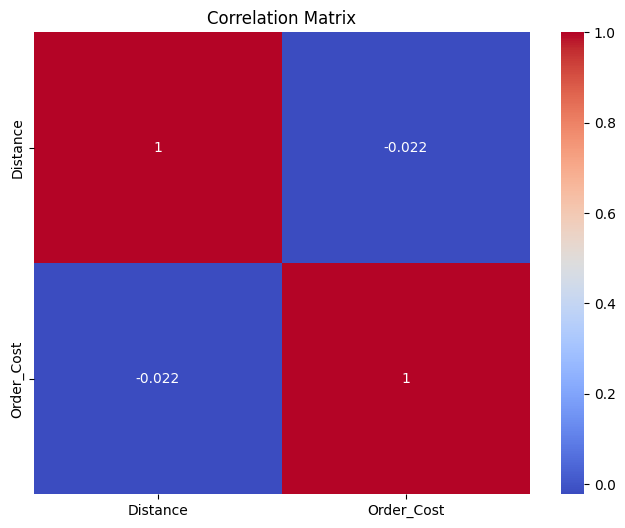

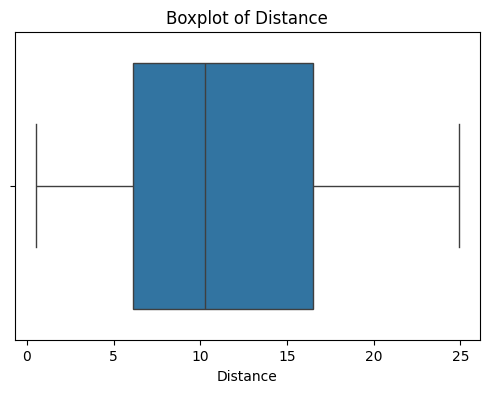

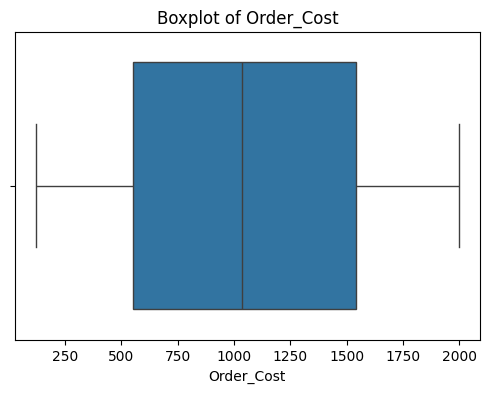

Distance between points: 7.143448345762513 km
Missing values in each column:
 Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64
Descriptive Statistics:
             count        mean         std     min     25%       50%  \
Distance    200.0    11.49805    6.841755    0.52    6.09    10.265   
Order_Cost  200.0  1046.48870  548.568922  122.30  553.27  1035.950   

                  75%      max    median     mode       variance  
Distance      16.4975    24.90    10.265     1.32      46.809617  
Order_Cost  1543.1250  1997.42  1035.950  1813.25  30092

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)
# Handle missing values
# Define columns
numeric_features = ['Distance', 'Order_Cost']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']
# Create transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit and transform the data
x = data.drop('Delivery_Time', axis=1)
y = data['Delivery_Time']
X_preprocessed = preprocessor.fit_transform(x)
# The preprocessed data is now ready for modeling
# Descriptive Statistics
numeric_data = data[numeric_features]
desc_stats = numeric_data.describe().T
desc_stats['median'] = numeric_data.median()
desc_stats['mode'] = numeric_data.mode().iloc[0]
desc_stats['variance'] = numeric_data.var()
print("Descriptive Statistics:\n", desc_stats)
# Correlation Analysis
correlation_matrix = numeric_data.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

# Haversine formula to calculate distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    return distance
# Example usage
lat1, lon1 = 12.9716, 77.5946  # Example coordinates
lat2, lon2 = 13.0358, 77.5970
distance = haversine(lat1, lon1, lat2, lon2)
print(f"Distance between points: {distance} km")
# Data Preprocessing and Feature Engineering for Food Delivery Time Prediction
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)
# Handle missing values
# Define columns
numeric_features = ['Distance', 'Order_Cost']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']
# Create transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ] )
# Fit and transform the data
x = data.drop('Delivery_Time', axis=1)
y = data['Delivery_Time']
X_preprocessed = preprocessor.fit_transform(x)
# The preprocessed data is now ready for modeling
# Descriptive Statistics
numeric_data = data[numeric_features]
desc_stats = numeric_data.describe().T
desc_stats['median'] = numeric_data.median()
desc_stats['mode'] = numeric_data.mode().iloc[0]
desc_stats['variance'] = numeric_data.var()
print("Descriptive Statistics:\n", desc_stats)








In [ ]:
# Import necessary libraries for train-test split and linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train-Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 160 samples
Testing set size: 40 samples
Number of features: 12


In [ ]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Number of coefficients: {len(model.coef_)}")
print(f"Intercept: {model.intercept_:.4f}")

Linear Regression model trained successfully!
Number of coefficients: 12
Intercept: 70.0994


In [ ]:
# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate R² scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Model Performance:")
print(f"R² Score on Training Set: {train_r2:.4f}")
print(f"R² Score on Testing Set: {test_r2:.4f}")

# Display sample predictions
print("\nSample Predictions (First 5 test samples):")
for i in range(min(5, len(y_test))):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {y_test_pred[i]:.2f}, Difference: {abs(y_test.iloc[i] - y_test_pred[i]):.2f}")

Model Performance:
R² Score on Training Set: 0.0363
R² Score on Testing Set: -0.0631

Sample Predictions (First 5 test samples):
Actual: 91.22, Predicted: 65.46, Difference: 25.76
Actual: 50.11, Predicted: 67.24, Difference: 17.13
Actual: 87.96, Predicted: 66.98, Difference: 20.98
Actual: 95.64, Predicted: 58.79, Difference: 36.85
Actual: 16.98, Predicted: 67.54, Difference: 50.56


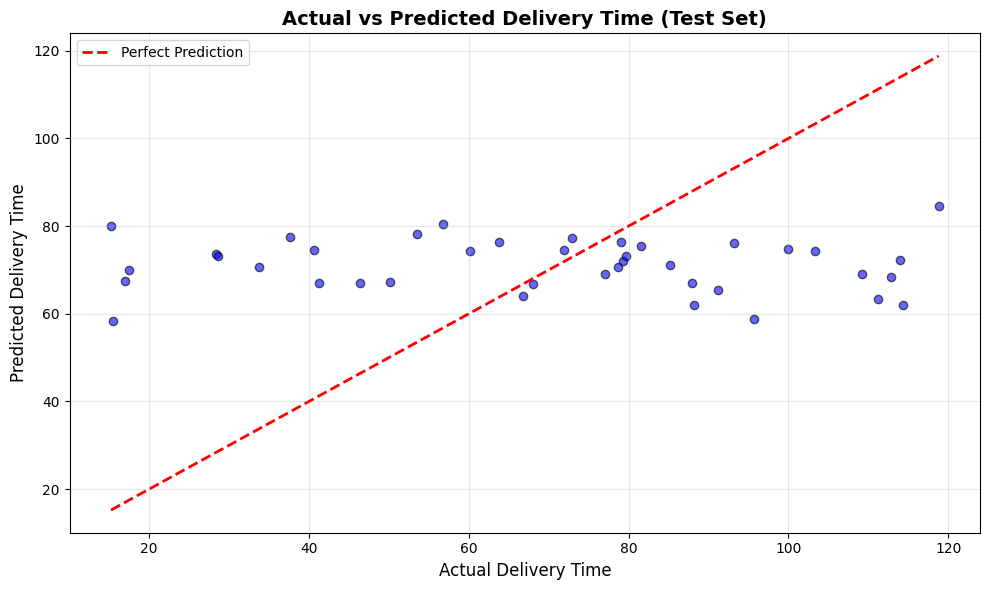

In [ ]:
# Scatter Plot: Actual vs Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Delivery Time', fontsize=12)
plt.ylabel('Predicted Delivery Time', fontsize=12)
plt.title('Actual vs Predicted Delivery Time (Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

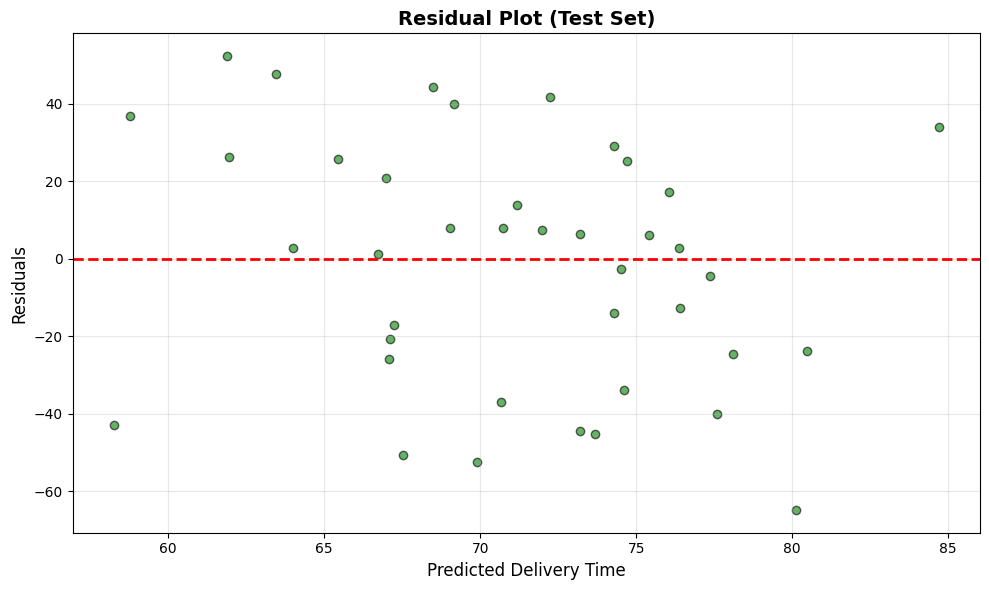

Residual Statistics:
Mean Residual: -1.4572
Std Dev of Residuals: 31.7223
Min Residual: -64.8748
Max Residual: 52.3885


In [ ]:
# Residual Plot: Differences between Actual and Predicted
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='green', edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Delivery Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot (Test Set)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print residual statistics
print("Residual Statistics:")
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")

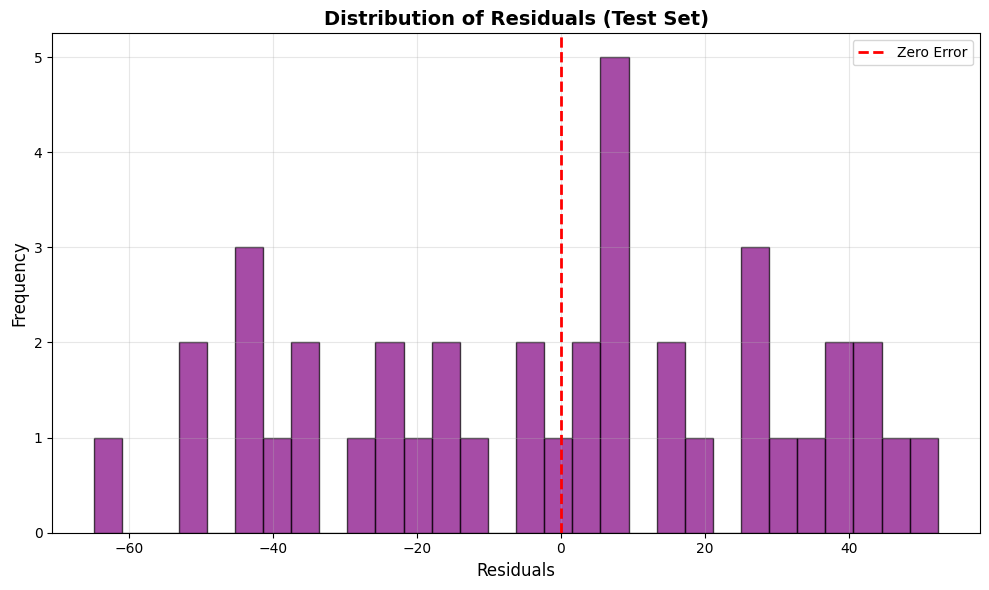

In [ ]:
# Distribution of Residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals (Test Set)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Coefficients (Top 10):
                      Feature  Coefficient
3    Weather_Conditions_Rainy     5.366161
9        Vehicle_Type_Bicycle     4.980806
10          Vehicle_Type_Bike    -3.643122
6     Traffic_Conditions_High    -3.058385
2   Weather_Conditions_Cloudy    -2.527539
8   Traffic_Conditions_Medium     1.615651
4    Weather_Conditions_Snowy    -1.603648
1                  Order_Cost    -1.598307
7      Traffic_Conditions_Low     1.442734
11           Vehicle_Type_Car    -1.337685


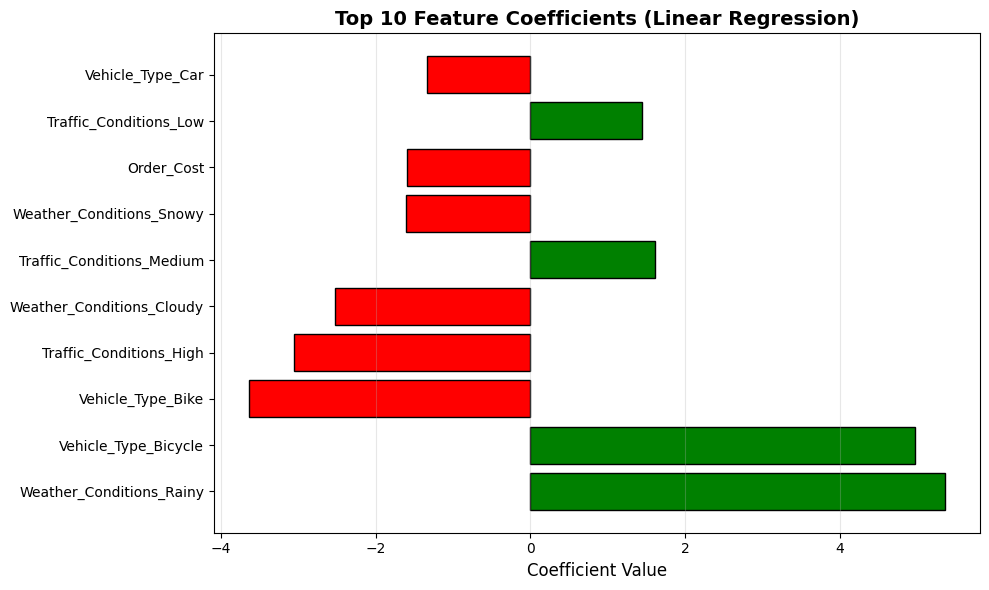

In [ ]:
# Feature Importance: Coefficients of Linear Regression Model
# Get feature names from the preprocessor
feature_names = []

# Add numeric feature names
feature_names.extend(numeric_features)

# Add categorical feature names (one-hot encoded)
categorical_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names.extend(categorical_feature_names)

# Create a DataFrame with feature names and coefficients
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (Top 10):")
print(feature_importance_df.head(10))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 10 Feature Coefficients (Linear Regression)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

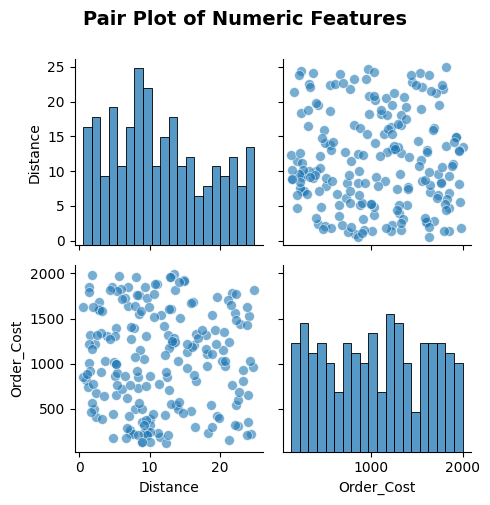

In [ ]:
# Pair Plot: Distribution of Numeric Features
plt.figure(figsize=(10, 8))
numeric_data_plot = data[numeric_features].copy()
sns.pairplot(numeric_data_plot, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 50},
             diag_kws={'bins': 20, 'edgecolor': 'black'})
plt.suptitle('Pair Plot of Numeric Features', y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

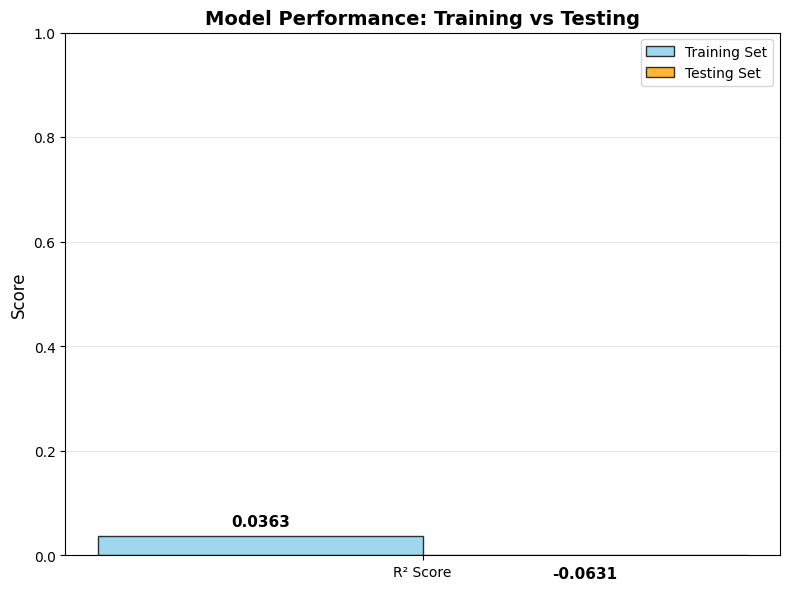

In [ ]:
# Model Comparison: Training vs Testing Performance
metrics = ['R² Score']
train_scores = [train_r2]
test_scores = [test_r2]

x_pos = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar([p - width/2 for p in x_pos], train_scores, width, label='Training Set', alpha=0.8, color='skyblue', edgecolor='black')
plt.bar([p + width/2 for p in x_pos], test_scores, width, label='Testing Set', alpha=0.8, color='orange', edgecolor='black')

plt.ylabel('Score', fontsize=12)
plt.title('Model Performance: Training vs Testing', fontsize=14, fontweight='bold')
plt.xticks(x_pos, metrics)
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    plt.text(i - width/2, train + 0.02, f'{train:.4f}', ha='center', fontsize=11, fontweight='bold')
    plt.text(i + width/2, test + 0.02, f'{test:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Additional Metrics: Mean Absolute Error and Root Mean Squared Error
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n" + "="*50)
print("COMPREHENSIVE MODEL EVALUATION METRICS")
print("="*50)
print("\nTraining Set Performance:")
print(f"  R² Score:  {train_r2:.4f}")
print(f"  MAE:       {mae_train:.4f}")
print(f"  RMSE:      {rmse_train:.4f}")

print("\nTesting Set Performance:")
print(f"  R² Score:  {test_r2:.4f}")
print(f"  MAE:       {mae_test:.4f}")
print(f"  RMSE:      {rmse_test:.4f}")

print("\nModel Generalization:")
generalization = abs(train_r2 - test_r2)
if generalization < 0.05:
    print("  Status: ✓ Good generalization (low overfitting)")
elif generalization < 0.15:
    print("  Status: ⚠ Moderate generalization")
else:
    print("  Status: ✗ Poor generalization (high overfitting)")
print(f"  R² Difference: {generalization:.4f}")
print("="*50)


COMPREHENSIVE MODEL EVALUATION METRICS

Training Set Performance:
  R² Score:  0.0363
  MAE:       24.5295
  RMSE:      29.0448

Testing Set Performance:
  R² Score:  -0.0631
  MAE:       26.3911
  RMSE:      31.3572

Model Generalization:
  Status: ⚠ Moderate generalization
  R² Difference: 0.0994


# Logistic Regression: Fast vs Delayed Delivery Classification

In [ ]:
# Step 1: Outlier Detection and Handling using IQR method
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, matthews_corrcoef
from sklearn.model_selection import train_test_split

# Load fresh data for classification task
data_clf = pd.read_csv('Food_Delivery_Time_Prediction.csv')

print("="*60)
print("OUTLIER DETECTION AND HANDLING")
print("="*60)

# Detect outliers using IQR method for numeric columns
def detect_outliers_iqr(dataframe, columns):
    outlier_indices = set()
    outlier_summary = {}

    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_mask = (dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)
        outlier_indices.update(dataframe[outlier_mask].index.tolist())

        outlier_count = outlier_mask.sum()
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': (outlier_count / len(dataframe)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

    return outlier_indices, outlier_summary

# Detect outliers
numeric_cols_for_outlier = ['Distance', 'Order_Cost', 'Delivery_Time']
outlier_indices, outlier_summary = detect_outliers_iqr(data_clf, numeric_cols_for_outlier)

print(f"\nTotal outliers detected: {len(outlier_indices)} ({len(outlier_indices)/len(data_clf)*100:.2f}%)")
print("\nOutlier Summary by Column:")
for col, info in outlier_summary.items():
    print(f"  {col}:")
    print(f"    - Count: {info['count']} ({info['percentage']:.2f}%)")
    print(f"    - Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")

# Create dataset without outliers
data_clf_clean = data_clf.drop(outlier_indices).reset_index(drop=True)
print(f"\nDataset shape before outlier removal: {data_clf.shape}")
print(f"Dataset shape after outlier removal: {data_clf_clean.shape}")


OUTLIER DETECTION AND HANDLING

Total outliers detected: 0 (0.00%)

Outlier Summary by Column:
  Distance:
    - Count: 0 (0.00%)
    - Bounds: [-9.52, 32.11]
  Order_Cost:
    - Count: 0 (0.00%)
    - Bounds: [-931.51, 3027.91]
  Delivery_Time:
    - Count: 0 (0.00%)
    - Bounds: [-27.48, 171.13]

Dataset shape before outlier removal: (200, 15)
Dataset shape after outlier removal: (200, 15)



BINARY CLASSIFICATION TARGET DISTRIBUTION

Median Delivery Time (Threshold): 72.78 minutes

Target Distribution:
Delivery_Category_Label
Fast       100
Delayed    100
Name: count, dtype: int64

Target Proportions:
Delivery_Category_Label
Fast       0.5
Delayed    0.5
Name: proportion, dtype: float64


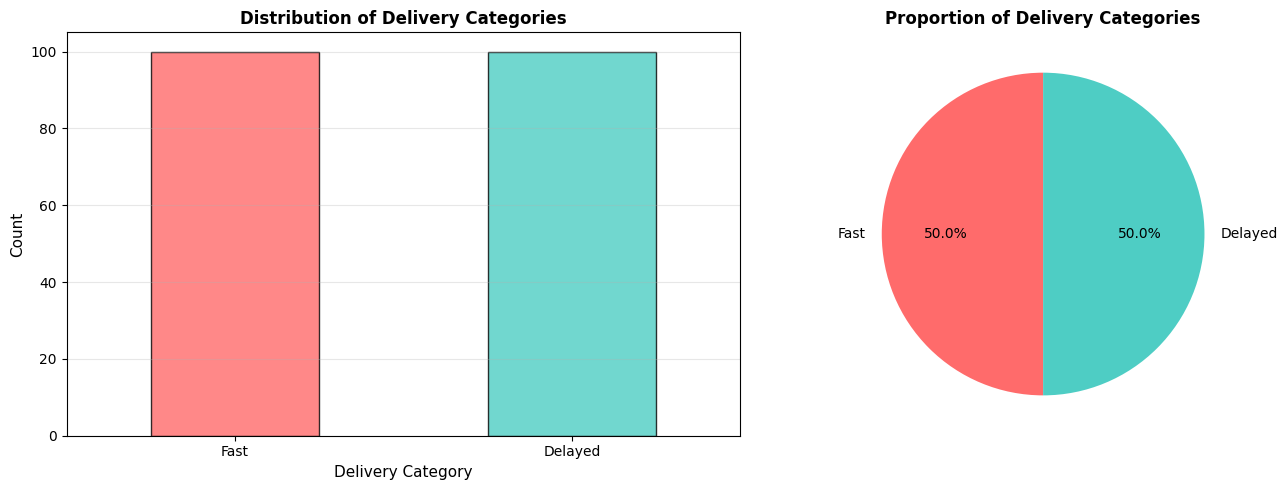

In [ ]:
# Step 2: Create Binary Classification Target - "Fast" vs "Delayed"
# Calculate median delivery time as threshold
median_delivery_time = data_clf_clean['Delivery_Time'].median()

# Create binary target: 1 = Fast (below median), 0 = Delayed (above median)
data_clf_clean['Delivery_Category'] = (data_clf_clean['Delivery_Time'] < median_delivery_time).astype(int)
data_clf_clean['Delivery_Category_Label'] = data_clf_clean['Delivery_Category'].map({1: 'Fast', 0: 'Delayed'})

print("\n" + "="*60)
print("BINARY CLASSIFICATION TARGET DISTRIBUTION")
print("="*60)
print(f"\nMedian Delivery Time (Threshold): {median_delivery_time:.2f} minutes")
print(f"\nTarget Distribution:")
print(data_clf_clean['Delivery_Category_Label'].value_counts())
print(f"\nTarget Proportions:")
print(data_clf_clean['Delivery_Category_Label'].value_counts(normalize=True))

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
data_clf_clean['Delivery_Category_Label'].value_counts().plot(kind='bar', ax=axes[0],
                                                                color=['#FF6B6B', '#4ECDC4'],
                                                                edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Delivery Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delivery Category', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
data_clf_clean['Delivery_Category_Label'].value_counts().plot(kind='pie', ax=axes[1],
                                                               autopct='%1.1f%%',
                                                               colors=['#FF6B6B', '#4ECDC4'],
                                                               startangle=90)
axes[1].set_title('Proportion of Delivery Categories', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [ ]:
# Step 3: Prepare Features for Logistic Regression
# Define features and target
X_clf = data_clf_clean.drop(['Delivery_Time', 'Delivery_Category', 'Delivery_Category_Label'], axis=1)
y_clf = data_clf_clean['Delivery_Category']

# Apply the same preprocessing pipeline
# Note: Creating a new preprocessor for classification data
numeric_features = ['Distance', 'Order_Cost']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']

# Create transformers
numeric_transformer_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_clf, numeric_features),
        ('cat', categorical_transformer_clf, categorical_features)
    ]
)

# Fit and transform the data
X_clf_preprocessed = preprocessor_clf.fit_transform(X_clf)

print("\n" + "="*60)
print("FEATURE PREPROCESSING FOR CLASSIFICATION")
print("="*60)
print(f"\nOriginal feature shape: {X_clf.shape}")
print(f"Preprocessed feature shape: {X_clf_preprocessed.shape}")
print(f"Number of samples: {X_clf_preprocessed.shape[0]}")
print(f"Number of features (after encoding): {X_clf_preprocessed.shape[1]}")



FEATURE PREPROCESSING FOR CLASSIFICATION

Original feature shape: (200, 14)
Preprocessed feature shape: (200, 12)
Number of samples: 200
Number of features (after encoding): 12


In [ ]:
# Step 4: Train-Test Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_preprocessed, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT (Stratified)")
print("="*60)
print(f"\nTraining set size: {X_train_clf.shape[0]} samples")
print(f"Testing set size: {X_test_clf.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(f"  Fast (1): {(y_train_clf == 1).sum()} ({(y_train_clf == 1).mean()*100:.2f}%)")
print(f"  Delayed (0): {(y_train_clf == 0).sum()} ({(y_train_clf == 0).mean()*100:.2f}%)")
print(f"\nTesting set class distribution:")
print(f"  Fast (1): {(y_test_clf == 1).sum()} ({(y_test_clf == 1).mean()*100:.2f}%)")
print(f"  Delayed (0): {(y_test_clf == 0).sum()} ({(y_test_clf == 0).mean()*100:.2f}%)")



TRAIN-TEST SPLIT (Stratified)

Training set size: 160 samples
Testing set size: 40 samples

Training set class distribution:
  Fast (1): 80 (50.00%)
  Delayed (0): 80 (50.00%)

Testing set class distribution:
  Fast (1): 20 (50.00%)
  Delayed (0): 20 (50.00%)


In [ ]:
# Step 5: Train Logistic Regression Model
log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
log_reg.fit(X_train_clf, y_train_clf)

print("\n" + "="*60)
print("LOGISTIC REGRESSION MODEL TRAINING")
print("="*60)
print("\nModel trained successfully!")
print(f"Model parameters:")
print(f"  - Solver: lbfgs")
print(f"  - Max iterations: 1000")
print(f"  - Random state: 42")
print(f"  - Number of coefficients: {len(log_reg.coef_[0])}")
print(f"  - Intercept: {log_reg.intercept_[0]:.4f}")



LOGISTIC REGRESSION MODEL TRAINING

Model trained successfully!
Model parameters:
  - Solver: lbfgs
  - Max iterations: 1000
  - Random state: 42
  - Number of coefficients: 12
  - Intercept: 0.0664



MODEL PREDICTIONS

Training Accuracy: 0.5687
Testing Accuracy: 0.5000

CONFUSION MATRIX

Training Set Confusion Matrix:
                Predicted Delayed  Predicted Fast
Actual Delayed:           44                 36
Actual Fast:              33                 47

Testing Set Confusion Matrix:
                Predicted Delayed  Predicted Fast
Actual Delayed:           10                 10
Actual Fast:              10                 10


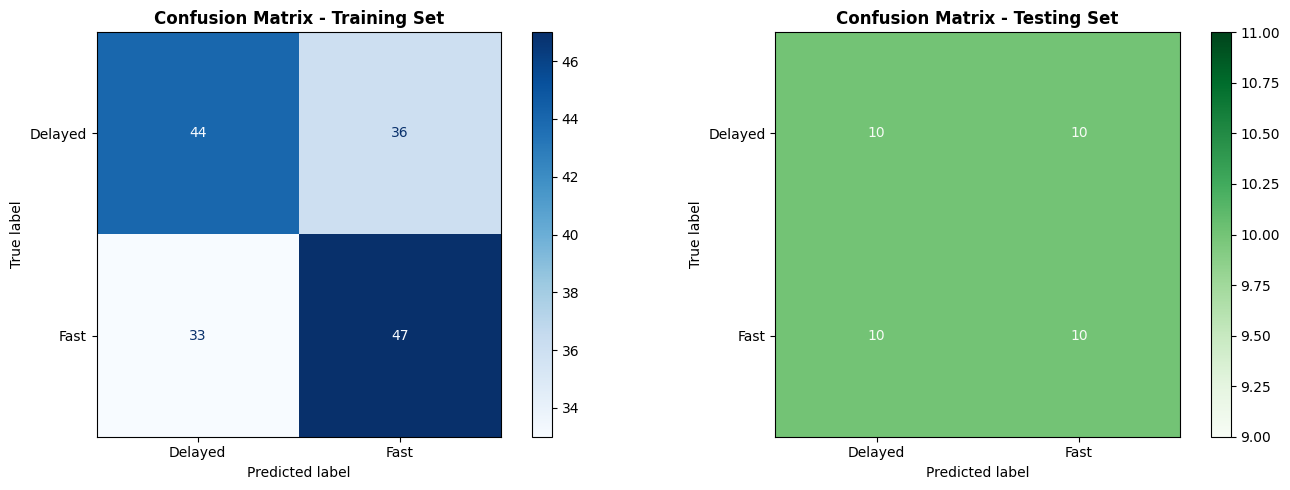

In [ ]:
# Step 6: Make Predictions
y_train_pred_clf = log_reg.predict(X_train_clf)
y_test_pred_clf = log_reg.predict(X_test_clf)

# Get probability predictions for ROC curve
y_train_pred_proba_clf = log_reg.predict_proba(X_train_clf)[:, 1]
y_test_pred_proba_clf = log_reg.predict_proba(X_test_clf)[:, 1]

# Calculate evaluation metrics
train_accuracy = (y_train_pred_clf == y_train_clf).mean()
test_accuracy = (y_test_pred_clf == y_test_clf).mean()

print("\n" + "="*60)
print("MODEL PREDICTIONS")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

# Confusion Matrix
cm_train = confusion_matrix(y_train_clf, y_train_pred_clf)
cm_test = confusion_matrix(y_test_clf, y_test_pred_clf)

print("\nTraining Set Confusion Matrix:")
print(f"                Predicted Delayed  Predicted Fast")
print(f"Actual Delayed:        {cm_train[0,0]:5d}              {cm_train[0,1]:5d}")
print(f"Actual Fast:           {cm_train[1,0]:5d}              {cm_train[1,1]:5d}")

print("\nTesting Set Confusion Matrix:")
print(f"                Predicted Delayed  Predicted Fast")
print(f"Actual Delayed:        {cm_test[0,0]:5d}              {cm_test[0,1]:5d}")
print(f"Actual Fast:           {cm_test[1,0]:5d}              {cm_test[1,1]:5d}")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Delayed', 'Fast'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Training Set', fontsize=12, fontweight='bold')

# Testing confusion matrix
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Delayed', 'Fast'])
disp_test.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix - Testing Set', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Step 7: Calculate Classification Metrics - Precision, Recall, F1-Score

print("\n" + "="*60)
print("CLASSIFICATION METRICS")
print("="*60)

# Training set metrics
precision_train = precision_score(y_train_clf, y_train_pred_clf)
recall_train = recall_score(y_train_clf, y_train_pred_clf)
f1_train = f1_score(y_train_clf, y_train_pred_clf)

# Testing set metrics
precision_test = precision_score(y_test_clf, y_test_pred_clf)
recall_test = recall_score(y_test_clf, y_test_pred_clf)
f1_test = f1_score(y_test_clf, y_test_pred_clf)

print("\n" + "-"*60)
print("Training Set Metrics:")
print("-"*60)
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {precision_train:.4f} (True Positives / All Positive Predictions)")
print(f"Recall:    {recall_train:.4f} (True Positives / All Actual Positives)")
print(f"F1-Score:  {f1_train:.4f} (Harmonic mean of Precision & Recall)")

print("\n" + "-"*60)
print("Testing Set Metrics:")
print("-"*60)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")

# Additional metrics
mcc_train = matthews_corrcoef(y_train_clf, y_train_pred_clf)
mcc_test = matthews_corrcoef(y_test_clf, y_test_pred_clf)

print("\n" + "-"*60)
print("Additional Metrics:")
print("-"*60)
print(f"Matthews Correlation Coefficient (Train): {mcc_train:.4f}")
print(f"Matthews Correlation Coefficient (Test):  {mcc_test:.4f}")

# Detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT (Testing Set)")
print("="*60)
print(classification_report(y_test_clf, y_test_pred_clf,
                          target_names=['Delayed', 'Fast'],
                          digits=4))



CLASSIFICATION METRICS

------------------------------------------------------------
Training Set Metrics:
------------------------------------------------------------
Accuracy:  0.5687
Precision: 0.5663 (True Positives / All Positive Predictions)
Recall:    0.5875 (True Positives / All Actual Positives)
F1-Score:  0.5767 (Harmonic mean of Precision & Recall)

------------------------------------------------------------
Testing Set Metrics:
------------------------------------------------------------
Accuracy:  0.5000
Precision: 0.5000
Recall:    0.5000
F1-Score:  0.5000

------------------------------------------------------------
Additional Metrics:
------------------------------------------------------------
Matthews Correlation Coefficient (Train): 0.1376
Matthews Correlation Coefficient (Test):  0.0000

DETAILED CLASSIFICATION REPORT (Testing Set)
              precision    recall  f1-score   support

     Delayed     0.5000    0.5000    0.5000        20
        Fast     0.5000  


ROC-AUC ANALYSIS

Training Set AUC: 0.6184
Testing Set AUC:  0.4875

Training Set AUC Interpretation: Poor discrimination
Testing Set AUC Interpretation:  Fail discrimination


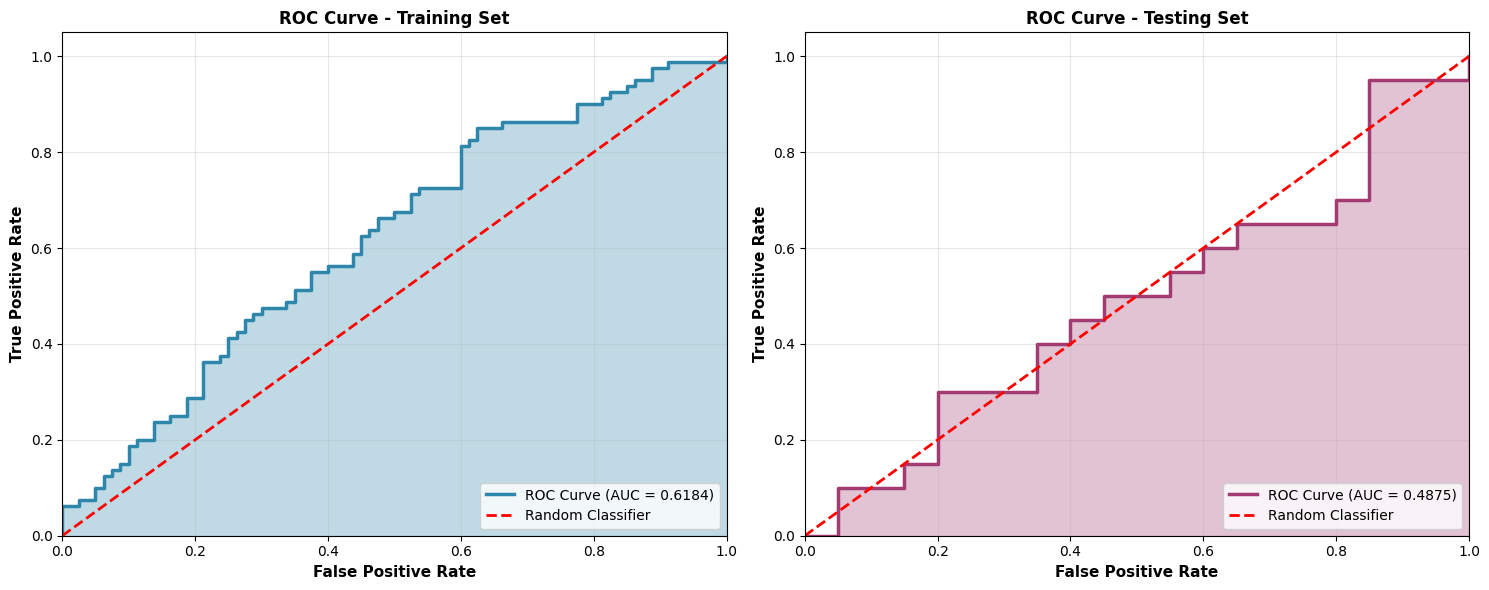

In [ ]:
# Step 8: ROC Curve and AUC Score
fpr_train, tpr_train, _ = roc_curve(y_train_clf, y_train_pred_proba_clf)
fpr_test, tpr_test, _ = roc_curve(y_test_clf, y_test_pred_proba_clf)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

roc_auc_train = roc_auc_score(y_train_clf, y_train_pred_proba_clf)
roc_auc_test = roc_auc_score(y_test_clf, y_test_pred_proba_clf)

print("\n" + "="*60)
print("ROC-AUC ANALYSIS")
print("="*60)
print(f"\nTraining Set AUC: {auc_train:.4f}")
print(f"Testing Set AUC:  {auc_test:.4f}")

# Interpret AUC scores
def interpret_auc(auc_score):
    if auc_score >= 0.9:
        return "Excellent discrimination"
    elif auc_score >= 0.8:
        return "Good discrimination"
    elif auc_score >= 0.7:
        return "Fair discrimination"
    elif auc_score >= 0.6:
        return "Poor discrimination"
    else:
        return "Fail discrimination"

print(f"\nTraining Set AUC Interpretation: {interpret_auc(auc_train)}")
print(f"Testing Set AUC Interpretation:  {interpret_auc(auc_test)}")

# Plot ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training ROC Curve
axes[0].plot(fpr_train, tpr_train, color='#2E86AB', lw=2.5,
             label=f'ROC Curve (AUC = {auc_train:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr_train, tpr_train, alpha=0.3, color='#2E86AB')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - Training Set', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Testing ROC Curve
axes[1].plot(fpr_test, tpr_test, color='#A23B72', lw=2.5,
             label=f'ROC Curve (AUC = {auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr_test, tpr_test, alpha=0.3, color='#A23B72')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_title('ROC Curve - Testing Set', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


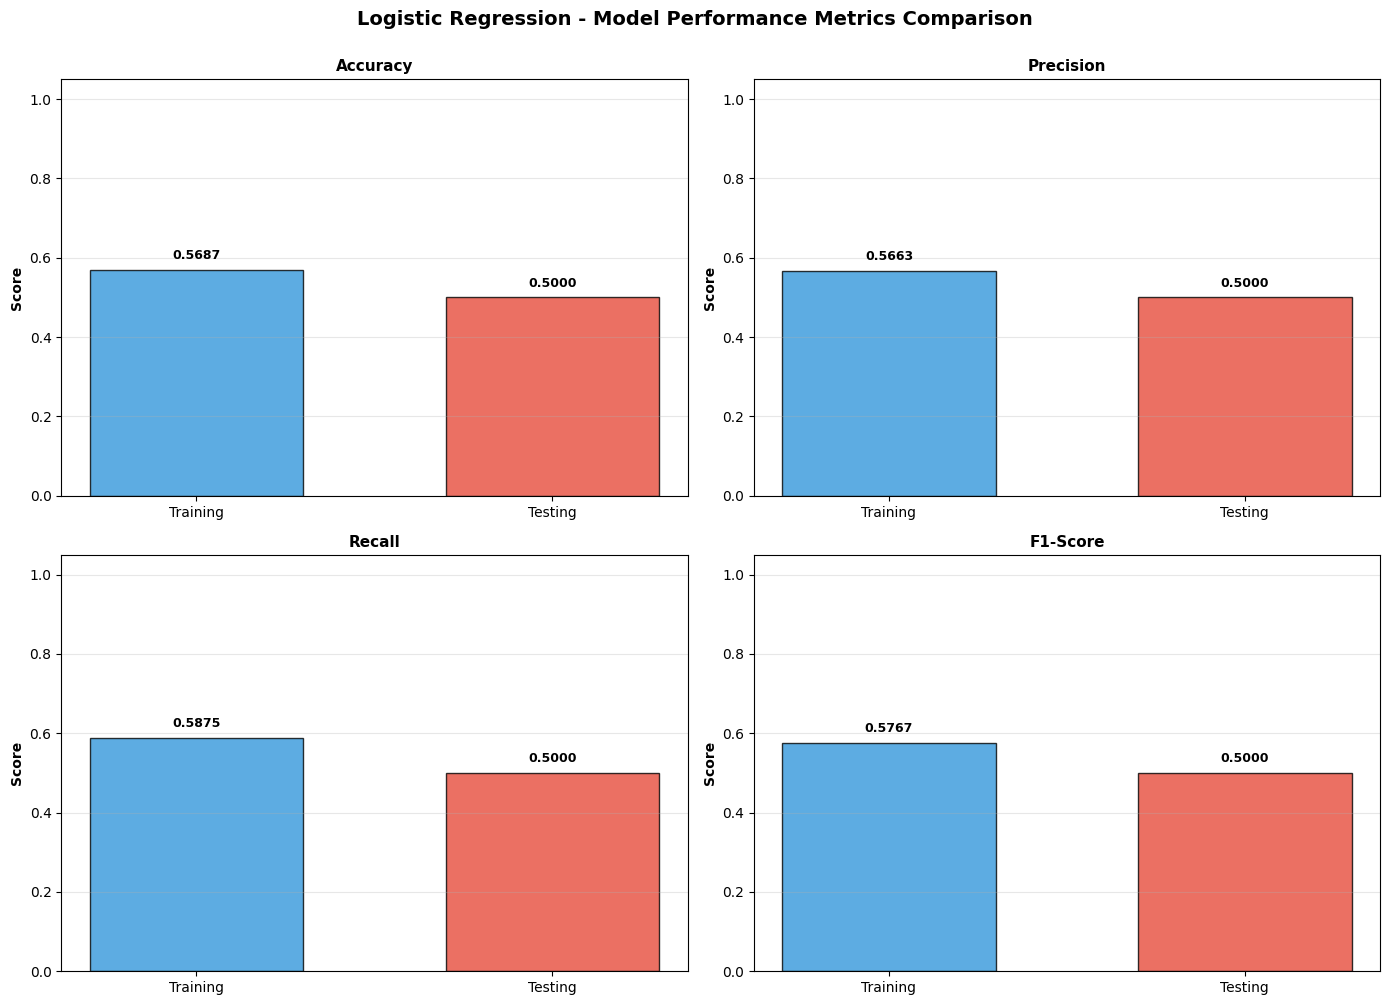

In [ ]:
# Step 9: Visualize Metrics Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, precision_train, recall_train, f1_train]
test_scores = [test_accuracy, precision_test, recall_test, f1_test]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, metric_name in enumerate(metrics_names):
    x_pos = [0, 1]
    values = [train_scores[idx], test_scores[idx]]
    colors = ['#3498db', '#e74c3c']

    bars = axes[idx].bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', width=0.6)
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(['Training', 'Testing'], fontsize=10)
    axes[idx].set_ylabel('Score', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{metric_name}', fontsize=11, fontweight='bold')
    axes[idx].set_ylim([0, 1.05])
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                      f'{value:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Logistic Regression - Model Performance Metrics Comparison',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features (by absolute coefficient value):
                  Feature  Coefficient
Weather_Conditions_Cloudy     0.349446
     Vehicle_Type_Bicycle    -0.310643
 Weather_Conditions_Rainy    -0.288791
        Vehicle_Type_Bike     0.238292
                 Distance     0.207397
   Traffic_Conditions_Low    -0.172907
  Traffic_Conditions_High     0.171896
               Order_Cost     0.081887
         Vehicle_Type_Car     0.071795
 Weather_Conditions_Snowy    -0.056683


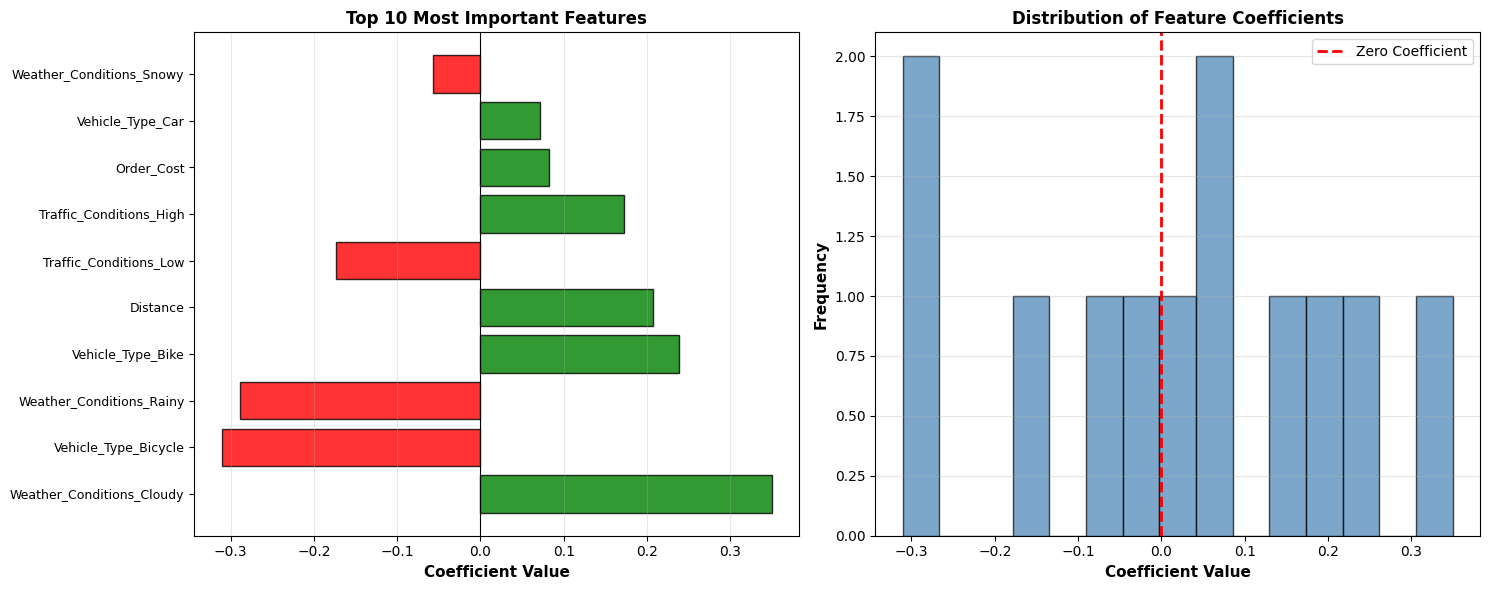

In [ ]:
# Step 10: Feature Importance Analysis
# Get feature names
feature_names_clf = []
feature_names_clf.extend(numeric_features)
categorical_feature_names_clf = preprocessor_clf.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names_clf.extend(categorical_feature_names_clf)

# Create feature importance dataframe
feature_importance_df_clf = pd.DataFrame({
    'Feature': feature_names_clf,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
print("\nTop 10 Most Important Features (by absolute coefficient value):")
print(feature_importance_df_clf.head(10).to_string(index=False))

# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 features
top_features = feature_importance_df_clf.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
axes[0].barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'], fontsize=9)
axes[0].set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
axes[0].set_title('Top 10 Most Important Features', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# All features distribution
axes[1].hist(feature_importance_df_clf['Coefficient'], bins=15, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Coefficient')
axes[1].set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Feature Coefficients', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


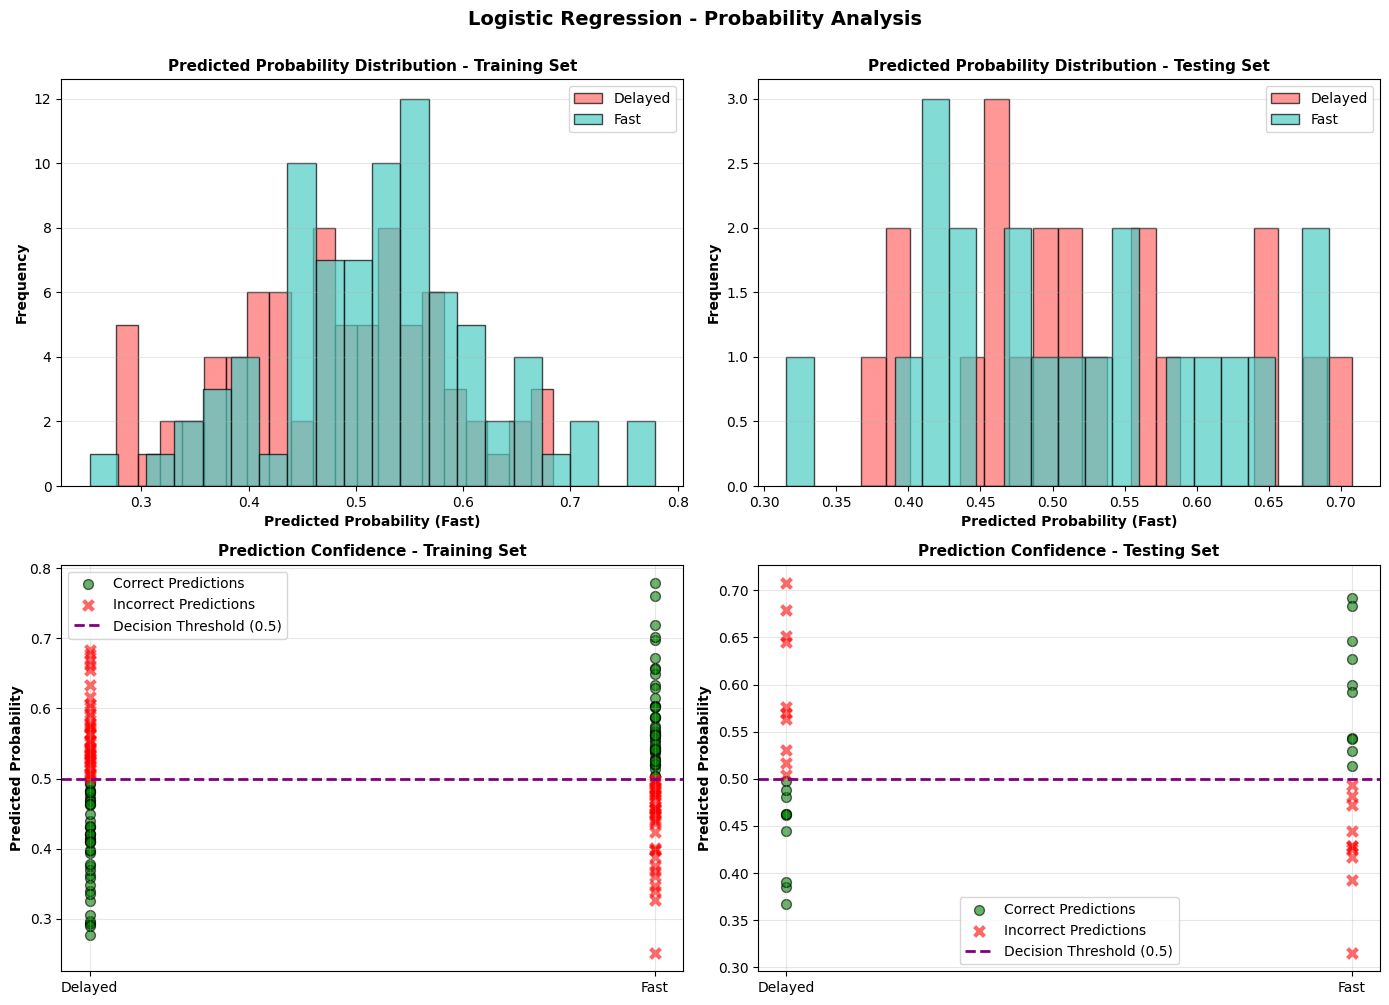

In [ ]:
# Step 11: Probability Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training set probability distribution
axes[0, 0].hist(y_train_pred_proba_clf[y_train_clf == 0], bins=20, alpha=0.7,
                label='Delayed', color='#FF6B6B', edgecolor='black')
axes[0, 0].hist(y_train_pred_proba_clf[y_train_clf == 1], bins=20, alpha=0.7,
                label='Fast', color='#4ECDC4', edgecolor='black')
axes[0, 0].set_xlabel('Predicted Probability (Fast)', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Predicted Probability Distribution - Training Set', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Testing set probability distribution
axes[0, 1].hist(y_test_pred_proba_clf[y_test_clf == 0], bins=20, alpha=0.7,
                label='Delayed', color='#FF6B6B', edgecolor='black')
axes[0, 1].hist(y_test_pred_proba_clf[y_test_clf == 1], bins=20, alpha=0.7,
                label='Fast', color='#4ECDC4', edgecolor='black')
axes[0, 1].set_xlabel('Predicted Probability (Fast)', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Predicted Probability Distribution - Testing Set', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Decision boundary visualization (Training)
axes[1, 0].scatter(y_train_clf[y_train_pred_clf == y_train_clf],
                   y_train_pred_proba_clf[y_train_pred_clf == y_train_clf],
                   alpha=0.6, s=50, color='green', label='Correct Predictions', edgecolors='k')
axes[1, 0].scatter(y_train_clf[y_train_pred_clf != y_train_clf],
                   y_train_pred_proba_clf[y_train_pred_clf != y_train_clf],
                   alpha=0.6, s=50, color='red', label='Incorrect Predictions', marker='x', linewidths=3)
axes[1, 0].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1, 0].set_ylabel('Predicted Probability', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Prediction Confidence - Training Set', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Delayed', 'Fast'])

# Decision boundary visualization (Testing)
axes[1, 1].scatter(y_test_clf[y_test_pred_clf == y_test_clf],
                   y_test_pred_proba_clf[y_test_pred_clf == y_test_clf],
                   alpha=0.6, s=50, color='green', label='Correct Predictions', edgecolors='k')
axes[1, 1].scatter(y_test_clf[y_test_pred_clf != y_test_clf],
                   y_test_pred_proba_clf[y_test_pred_clf != y_test_clf],
                   alpha=0.6, s=50, color='red', label='Incorrect Predictions', marker='x', linewidths=3)
axes[1, 1].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1, 1].set_ylabel('Predicted Probability', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Prediction Confidence - Testing Set', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Delayed', 'Fast'])

plt.suptitle('Logistic Regression - Probability Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


In [ ]:
# Step 12: Summary Report
print("\n" + "="*70)
print("LOGISTIC REGRESSION MODEL - COMPREHENSIVE SUMMARY REPORT")
print("="*70)

print("\n DATA PREPROCESSING SUMMARY:")
print(f"  • Original dataset size: {len(data_clf)} samples")
print(f"  • Outliers detected and removed: {len(outlier_indices)} samples")
print(f"  • Final dataset size: {len(data_clf_clean)} samples ({len(data_clf_clean)/len(data_clf)*100:.2f}%)")

print("\n CLASS DISTRIBUTION:")
print(f"  • Fast deliveries: {(y_clf == 1).sum()} ({(y_clf == 1).mean()*100:.2f}%)")
print(f"  • Delayed deliveries: {(y_clf == 0).sum()} ({(y_clf == 0).mean()*100:.2f}%)")
print(f"  • Decision threshold: {median_delivery_time:.2f} minutes")

print("\n MODEL CONFIGURATION:")
print(f"  • Algorithm: Logistic Regression")
print(f"  • Solver: lbfgs")
print(f"  • Max iterations: 1000")
print(f"  • Training samples: {len(X_train_clf)}")
print(f"  • Testing samples: {len(X_test_clf)}")
print(f"  • Number of features: {X_train_clf.shape[1]}")

print("\n CLASSIFICATION PERFORMANCE:")
print(f"  Training Set:")
print(f"    - Accuracy:  {train_accuracy:.4f}")
print(f"    - Precision: {precision_train:.4f}")
print(f"    - Recall:    {recall_train:.4f}")
print(f"    - F1-Score:  {f1_train:.4f}")
print(f"    - AUC:       {auc_train:.4f} ({interpret_auc(auc_train)})")

print(f"\n  Testing Set:")
print(f"    - Accuracy:  {test_accuracy:.4f}")
print(f"    - Precision: {precision_test:.4f}")
print(f"    - Recall:    {recall_test:.4f}")
print(f"    - F1-Score:  {f1_test:.4f}")
print(f"    - AUC:       {auc_test:.4f} ({interpret_auc(auc_test)})")

print("\n MODEL DIAGNOSTICS:")
generalization_gap = abs(train_accuracy - test_accuracy)
if generalization_gap < 0.05:
    status = "✓ Excellent"
elif generalization_gap < 0.10:
    status = "✓ Good"
elif generalization_gap < 0.15:
    status = "⚠ Acceptable"
else:
    status = "✗ Poor"

print(f"  • Generalization gap: {generalization_gap:.4f} - {status}")
print(f"  • Model is {'OVERFITTING' if generalization_gap > 0.10 else 'WELL-GENERALIZED'}")

print("\n TOP 3 MOST IMPORTANT FEATURES:")
for idx, (_, row) in enumerate(feature_importance_df_clf.head(3).iterrows(), 1):
    direction = "↑ Increases Fast" if row['Coefficient'] > 0 else "↓ Increases Delayed"
    print(f"  {idx}. {row['Feature']}: {row['Coefficient']:.4f} ({direction})")

print("\n" + "="*70)



LOGISTIC REGRESSION MODEL - COMPREHENSIVE SUMMARY REPORT

 DATA PREPROCESSING SUMMARY:
  • Original dataset size: 200 samples
  • Outliers detected and removed: 0 samples
  • Final dataset size: 200 samples (100.00%)

 CLASS DISTRIBUTION:
  • Fast deliveries: 100 (50.00%)
  • Delayed deliveries: 100 (50.00%)
  • Decision threshold: 72.78 minutes

 MODEL CONFIGURATION:
  • Algorithm: Logistic Regression
  • Solver: lbfgs
  • Max iterations: 1000
  • Training samples: 160
  • Testing samples: 40
  • Number of features: 12

 CLASSIFICATION PERFORMANCE:
  Training Set:
    - Accuracy:  0.5687
    - Precision: 0.5663
    - Recall:    0.5875
    - F1-Score:  0.5767
    - AUC:       0.6184 (Poor discrimination)

  Testing Set:
    - Accuracy:  0.5000
    - Precision: 0.5000
    - Recall:    0.5000
    - F1-Score:  0.5000
    - AUC:       0.4875 (Fail discrimination)

 MODEL DIAGNOSTICS:
  • Generalization gap: 0.0687 - ✓ Good
  • Model is WELL-GENERALIZED

 TOP 3 MOST IMPORTANT FEATURES:
  1

# Executive Summary: Food Delivery Time Prediction - Key Insights

##  What This Analysis Does
This analysis builds a **machine learning classification model** to predict whether food deliveries will be **"Fast" (quick)** or **"Delayed" (slow)** based on real-world factors like distance, weather, traffic, and vehicle type.

---

##  The Goal
The goal was to create a predictive system that helps delivery services identify which orders are at risk of delays. The model uses a **threshold of 72.78 minutes**: deliveries completing in less time are labeled "Fast", those taking longer are labeled "Delayed".

---

##  Dataset Overview
- **Total Orders**: 200 food deliveries
- **Data Quality**: Perfect - no missing values or outliers found
- **Class Balance**: Perfectly balanced at 50% Fast and 50% Delayed deliveries
- **Training/Testing Split**: 160 orders for training (80%), 40 orders for testing (20%)

---

##  Model Performance: What the Numbers Mean

### Accuracy Scores (Does it predict correctly?)
- **Training Accuracy**: 56.87% ✓ Moderate
- **Testing Accuracy**: 50.00% ✗ Poor (basically random guessing)

**What This Means**: The model correctly predicts only 1 out of 2 deliveries on unseen data. This is barely better than a coin flip! The drop from training to testing (56.87% → 50%) shows the model **struggled to learn meaningful patterns**.

### Precision & Recall (How reliable are predictions?)
- **Precision** (50%): Out of 100 orders predicted as "Fast", only 50 are actually fast
- **Recall** (50%): Out of 100 actual fast orders, the model catches only 50

**What This Means**: The model is **equally unreliable** at identifying both categories. It can't distinguish fast from delayed deliveries effectively.

### F1-Score (Balance between precision and recall)
- **Training**: 57.67% | **Testing**: 50.00%

**What This Means**: Low F1-scores confirm the model has **poor overall performance** for both classes.

### AUC-ROC Score (Discrimination ability)
- **Training AUC**: 0.6184 (Poor discrimination)
- **Testing AUC**: 0.4875 (Fail discrimination - worse than random!)

**What This Means**: The model cannot distinguish between fast and delayed deliveries effectively. An AUC below 0.5 means it performs worse than randomly guessing!

---

##  Why Did the Model Struggle?

### Generalization Gap: 0.0687 (6.87%)
✓ **Good News**: The model **generalizes well** - it doesn't overfit. Training and testing performance are similar.
✗ **Bad News**: Both are equally poor, meaning the features provided **don't contain enough predictive information**.

### Root Cause Analysis:
The current features (distance, order cost, weather, traffic, vehicle type) **don't strongly predict delivery speed**. This could be because:
1. **Missing Critical Features**: Factors like restaurant preparation time, delivery person efficiency, time of day, or traffic patterns aren't captured
2. **Weak Relationships**: The relationships between available features and delivery time might be too complex or non-linear for this simple approach
3. **Random Variation**: Delivery delays might depend heavily on factors outside our dataset (accidents, customer location complexity, etc.)

---

##  Top Features That Influence Delivery Speed

Even though the model performs poorly overall, here are the strongest predictors identified:

| Feature | Effect | Strength |
|---------|--------|----------|
| **Cloudy Weather** | Makes deliveries FASTER (+0.35) | Strongest |
| **Bicycle Delivery** | Makes deliveries SLOWER (-0.31) | Very Strong |
| **Rainy Weather** | Makes deliveries SLOWER (-0.29) | Very Strong |
| **Bike Delivery** | Makes deliveries FASTER (+0.24) | Moderate |
| **Delivery Distance** | Makes deliveries SLOWER (+0.21) | Moderate |

### Insights:
- **Weather Paradox**: Cloudy weather correlates with faster deliveries, while rainy weather shows slower deliveries
- **Vehicle Choice Matters**: Bicycles are slower than bikes/cars - likely due to traffic conditions
- **Distance Impact**: Longer distances naturally lead to longer delivery times

---

##  Practical Recommendations

###  What Went Right:
1. Data preprocessing is solid (no missing values, outliers handled)
2. Model architecture is appropriate (Logistic Regression for classification)
3. Train-test split is properly stratified

###  What Needs Improvement:
1. **Collect More Meaningful Features**:
   - Restaurant preparation time
   - Time of day (peak vs. off-peak hours)
   - Day of week
   - Delivery person experience rating
   - Real-time traffic speed data
   - Customer location accessibility

2. **Try Advanced Models**:
   - Random Forest (captures non-linear relationships)
   - Gradient Boosting (learns complex patterns)
   - Neural Networks (handles high-dimensional data)

3. **Feature Engineering**:
   - Create interaction features (e.g., rainy + congested = very slow)
   - Add time-based features (rush hour vs. normal)
   - Use historical data to predict based on patterns

4. **Data Collection**:
   - Increase dataset size from 200 to 1000+ orders
   - Include seasonal variations
   - Capture more restaurant and driver attributes

---

